# TP2 Starter Pack: Image-to-Prompt Inversion

This notebook provides the basic utilities needed for TP2:

- mount Google Drive in Colab / VS Code Colab extension;
- load the TP2 target images;
- extract the fixed render seed from each target filename;
- load the LCM generator `SimianLuo/LCM_Dreamshaper_v7`;
- generate images from prompts using the same settings as the target images;
- save generated images and metadata.

The goal of TP2 is to find prompts that reproduce the target images as closely as possible when rendered with the same LCM setup.


## 1. Install Dependencies

Run this cell first in Colab.


In [3]:
# Install the PyTorch Diffusers stack.
# Pillow 12 can break some Diffusers/Transformers imports in Colab Python 3.12
# with errors such as: cannot import name '_Ink' from PIL._typing.
# lpips is needed for the mandatory perceptual-distance metric.
!pip install -q -U "diffusers[torch]" transformers accelerate safetensors matplotlib "pandas<3" lpips
!pip install -q -U --force-reinstall "Pillow<12"


## 2. Google Drive and Target Paths

This section uses the folder structure in Google Drive. In the VS Code Colab extension, the runtime sees Google Drive under `/content/drive/MyDrive`.

Expected Drive layout:

```text
MyDrive/content/GENAI_TP2/tp2-chosen/*.png
MyDrive/content/GENAI_TP2/output/
```

The cell also accepts `GENAI_TP2` directly in `MyDrive`, and accepts `tp2` instead of `tp2-chosen` if that is the folder name you used.


In [4]:
from pathlib import Path
import zipfile
import urllib.request

# Clear old kernel state first. If this cell fails, later cells will not reuse stale paths.
TARGET_DIR = None
target_images = []

MOUNT_GOOGLE_DRIVE = True

if MOUNT_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as exc:
        print("Google Drive mount skipped:", exc)

# Optional online URL for a zip with the target images.
# Leave empty if targets are already available locally or in Drive.
TARGETS_ZIP_URL = ""

CONTENT_DIR = Path("/content")
DRIVE_ROOT = Path("/content/drive/MyDrive")

PROJECT_DIR_CANDIDATES = [
    DRIVE_ROOT / "content" / "GENAI_TP2",
    DRIVE_ROOT / "GENAI_TP2",
    CONTENT_DIR / "GENAI_TP2",
    Path("GENAI_TP2"),
]

if DRIVE_ROOT.exists():
    PROJECT_DIR = next((path for path in PROJECT_DIR_CANDIDATES[:2] if path.exists()), DRIVE_ROOT / "content" / "GENAI_TP2")
elif CONTENT_DIR.exists():
    PROJECT_DIR = CONTENT_DIR / "GENAI_TP2"
else:
    PROJECT_DIR = Path("GENAI_TP2")

PROJECT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR_CANDIDATES = [
    PROJECT_DIR / "output",
    PROJECT_DIR / "outputs",
]
OUTPUT_DIR = next((path for path in OUTPUT_DIR_CANDIDATES if path.exists()), PROJECT_DIR / "output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_PROJECT_DIR = PROJECT_DIR
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}
EXPECTED_TARGET_NAMES = {
    "1159_25.png",
    "1159_29.png",
    "1159_3.png",
    "1159_7.png",
    "7836.png",
    "9338.png",
}

def list_target_images(path):
    path = Path(path)
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        return [path]
    if not path.exists():
        return []
    return sorted(p for p in path.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)

def has_expected_targets(path):
    found_names = {image_path.name for image_path in list_target_images(path)}
    return EXPECTED_TARGET_NAMES.issubset(found_names)

TARGET_DIR_CANDIDATES = [
    PROJECT_DIR / "tp2-chosen",
    PROJECT_DIR / "tp2",
    PROJECT_DIR / "tp2_targets",
    DRIVE_ROOT / "content" / "GENAI_TP2" / "tp2-chosen",
    DRIVE_ROOT / "content" / "GENAI_TP2" / "tp2",
    DRIVE_ROOT / "GENAI_TP2" / "tp2-chosen",
    DRIVE_ROOT / "GENAI_TP2" / "tp2",
    CONTENT_DIR / "GENAI_TP2" / "tp2-chosen",
    CONTENT_DIR / "GENAI_TP2" / "tp2",
    CONTENT_DIR / "tp2-chosen",
    CONTENT_DIR / "tp2",
    Path("tp2-chosen"),
    Path("tp2"),
]

ZIP_CANDIDATES = [
    PROJECT_DIR / "tp2-chosen.zip",
    PROJECT_DIR / "tp2.zip",
    DRIVE_ROOT / "content" / "GENAI_TP2" / "tp2-chosen.zip",
    DRIVE_ROOT / "content" / "GENAI_TP2" / "tp2.zip",
    DRIVE_ROOT / "GENAI_TP2" / "tp2-chosen.zip",
    DRIVE_ROOT / "GENAI_TP2" / "tp2.zip",
    CONTENT_DIR / "tp2-chosen.zip",
    CONTENT_DIR / "tp2.zip",
    Path("tp2-chosen.zip"),
    Path("tp2.zip"),
]

# Download optional online zip.
if TARGETS_ZIP_URL:
    LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    downloaded_zip = LOCAL_PROJECT_DIR / "tp2-chosen.zip"
    urllib.request.urlretrieve(TARGETS_ZIP_URL, downloaded_zip)
    ZIP_CANDIDATES.insert(0, downloaded_zip)
    print("Downloaded targets zip to", downloaded_zip)

# Extract first available zip if no complete folder with images exists yet.
if not any(has_expected_targets(candidate) for candidate in TARGET_DIR_CANDIDATES):
    for zip_path in ZIP_CANDIDATES:
        if zip_path.exists():
            extract_dir = CONTENT_DIR / "tp2-chosen" if CONTENT_DIR.exists() else Path("tp2-chosen")
            extract_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path) as zf:
                zf.extractall(extract_dir)
            print(f"Extracted {zip_path} -> {extract_dir}")
            break

for candidate in TARGET_DIR_CANDIDATES:
    if has_expected_targets(candidate):
        TARGET_DIR = candidate
        break

if TARGET_DIR is None:
    checked_locations = "\n".join(f"- {path}" for path in TARGET_DIR_CANDIDATES + ZIP_CANDIDATES)
    raise FileNotFoundError(
        "No complete TP2 target set found. Check that the six PNG files are inside "
        "MyDrive/content/GENAI_TP2/tp2-chosen or MyDrive/GENAI_TP2/tp2-chosen.\n\n"
        f"Expected files: {sorted(EXPECTED_TARGET_NAMES)}\n\n"
        f"Checked locations:\n{checked_locations}"
    )

target_images = list_target_images(TARGET_DIR)
print("Project folder:", PROJECT_DIR)
print("Target folder:", TARGET_DIR)
print("Output folder:", OUTPUT_DIR)
print("Number of targets:", len(target_images))
target_images


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/content/GENAI_TP2
Target folder: /content/drive/MyDrive/content/GENAI_TP2/tp2-chosen
Output folder: /content/drive/MyDrive/content/GENAI_TP2/outputs
Number of targets: 6


[PosixPath('/content/drive/MyDrive/content/GENAI_TP2/tp2-chosen/1159_25.png'),
 PosixPath('/content/drive/MyDrive/content/GENAI_TP2/tp2-chosen/1159_29.png'),
 PosixPath('/content/drive/MyDrive/content/GENAI_TP2/tp2-chosen/1159_3.png'),
 PosixPath('/content/drive/MyDrive/content/GENAI_TP2/tp2-chosen/1159_7.png'),
 PosixPath('/content/drive/MyDrive/content/GENAI_TP2/tp2-chosen/7836.png'),
 PosixPath('/content/drive/MyDrive/content/GENAI_TP2/tp2-chosen/9338.png')]

## 3. Utilities: Seeds, Display, and Output Folders

The target filename has two useful parts:

- the render seed is the first numeric block in the filename;
- the optional suffix after `_` identifies a different target variant, but it is not used as the LCM seed.

Examples:

- `7836.png` uses render seed `7836` and has no suffix;
- `1159_25.png` uses render seed `1159` and target suffix `25`.

So `1159_25.png`, `1159_29.png`, `1159_3.png`, and `1159_7.png` intentionally share render seed `1159`; they are still different targets because their suffixes and visual contents are different.


In [5]:
import csv
import json
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image


def filename_seed_parts(path, fallback=2026):
    stem = Path(path).stem
    match = re.match(r"^(\d+)(?:_(.+))?$", stem)
    if not match:
        return fallback, ""
    render_seed = int(match.group(1))
    target_suffix = match.group(2) or ""
    return render_seed, target_suffix


def seed_from_filename(path, fallback=2026):
    render_seed, _ = filename_seed_parts(path, fallback=fallback)
    return render_seed


def safe_stem(path):
    return "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in Path(path).stem)


def load_image(path):
    return Image.open(path).convert("RGB")


def create_run_dir(base_dir=OUTPUT_DIR, identity="student_run"):
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = Path(base_dir) / f"{timestamp}_{identity}"
    run_dir.mkdir(parents=True, exist_ok=False)
    return run_dir


def write_csv(path, rows):
    rows = list(rows)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        Path(path).write_text("")
        return
    fieldnames = []
    for row in rows:
        for key in row.keys():
            if key not in fieldnames:
                fieldnames.append(key)
    with open(path, "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def show_images(paths, cols=3, title=None):
    paths = list(paths)
    if not paths:
        print("No images to show.")
        return
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    for ax in [ax for row in axes for ax in row]:
        ax.axis("off")
    for ax, path in zip([ax for row in axes for ax in row], paths):
        ax.imshow(load_image(path))
        ax.set_title(Path(path).name)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


for path in target_images:
    render_seed, target_suffix = filename_seed_parts(path)
    suffix_label = target_suffix if target_suffix else "none"
    print(Path(path).name, "-> render_seed", render_seed, "| target_suffix", suffix_label)


1159_25.png -> render_seed 1159 | target_suffix 25
1159_29.png -> render_seed 1159 | target_suffix 29
1159_3.png -> render_seed 1159 | target_suffix 3
1159_7.png -> render_seed 1159 | target_suffix 7
7836.png -> render_seed 7836 | target_suffix none
9338.png -> render_seed 9338 | target_suffix none


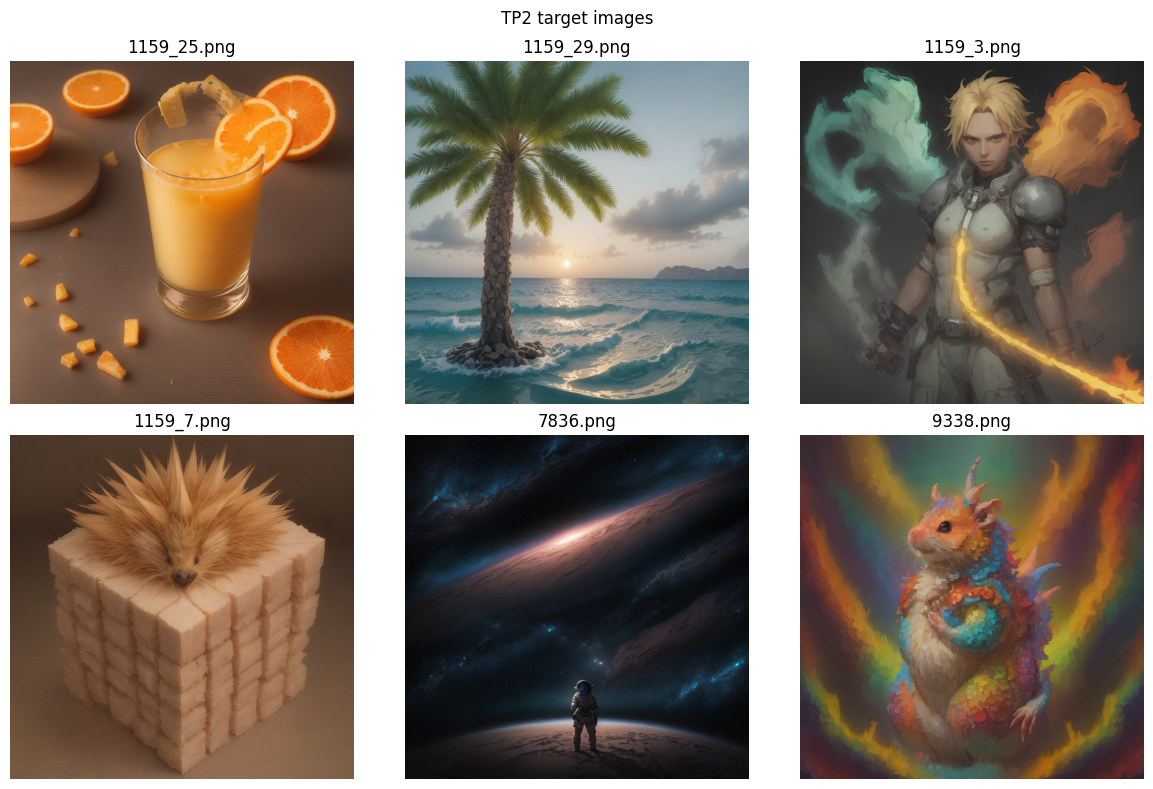

In [6]:
show_images(target_images, cols=3, title="TP2 target images")


## 4. Load the LCM Generator

These are the fixed generation settings used for TP2 targets.

In [7]:
from dataclasses import dataclass
import os
import warnings

# Avoid noisy, harmless warnings in Colab/VS Code Colab.
os.environ["HF_HUB_DISABLE_IMPLICIT_TOKEN"] = "1"
warnings.filterwarnings("ignore", message="Flax classes are deprecated.*")

import torch
from diffusers import DiffusionPipeline


@dataclass(frozen=True)
class LCMConfig:
    model_id: str = "SimianLuo/LCM_Dreamshaper_v7"
    seed: int = 2026  # fallback only; target filenames define the real render seed
    num_inference_steps: int = 8
    guidance_scale: float = 8.0
    lcm_origin_steps: int = 50
    width: int = 768
    height: int = 768


config = LCMConfig()


def default_device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


device = default_device()
print("Using device:", device)


def load_lcm_pipeline(config):
    dtype = torch.float16 if device == "cuda" else torch.float32
    pipe = DiffusionPipeline.from_pretrained(
        config.model_id,
        torch_dtype=dtype,
        use_safetensors=True,
        token=False,
    )
    if hasattr(pipe, "safety_checker"):
        pipe.safety_checker = None
    pipe.to(device)
    return pipe


pipe = load_lcm_pipeline(config)
print("LCM pipeline loaded:", config.model_id)
print("LCM dtype:", torch.float16 if device == "cuda" else torch.float32)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

LCM pipeline loaded: SimianLuo/LCM_Dreamshaper_v7
LCM dtype: torch.float16


## 5. Generate and Save Images

Use `render_prompt_for_target(...)` to render a prompt with the seed encoded in the target filename.

In [8]:
def render_prompt(prompt, seed, pipe=pipe, config=config):
    generator_device = "cpu" if device == "mps" else device
    generator = torch.Generator(device=generator_device).manual_seed(seed)
    image = pipe(
        prompt=prompt,
        num_inference_steps=config.num_inference_steps,
        guidance_scale=config.guidance_scale,
        lcm_origin_steps=config.lcm_origin_steps,
        width=config.width,
        height=config.height,
        output_type="pil",
        generator=generator,
    ).images[0]
    return image


def render_prompt_for_target(prompt, target_path):
    seed = seed_from_filename(target_path, config.seed)
    return render_prompt(prompt, seed=seed)


def save_generated_image(image, run_dir, target_path, prompt_index=1):
    target_dir = Path(run_dir) / safe_stem(target_path)
    target_dir.mkdir(parents=True, exist_ok=True)
    path = target_dir / f"candidate_{prompt_index:03d}.png"
    image.save(path)
    return path


## 6. Evaluation Metrics

These functions compute the mandatory image-side metrics: CLIP image-image similarity, LPIPS with AlexNet, and pixel RMSE.

In [9]:
import math
import numpy as np
import pandas as pd
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor
import lpips


EVAL_CLIP_MODEL_ID = "openai/clip-vit-large-patch14"


def load_evaluation_models(device=device):
    eval_device = device if device in {"cuda", "mps"} else "cpu"
    clip_model = CLIPModel.from_pretrained(EVAL_CLIP_MODEL_ID).to(eval_device).eval()
    clip_processor = CLIPProcessor.from_pretrained(EVAL_CLIP_MODEL_ID)
    lpips_model = lpips.LPIPS(net="alex").to(eval_device).eval()
    return eval_device, clip_model, clip_processor, lpips_model


eval_device, clip_model, clip_processor, lpips_model = load_evaluation_models()
print("Evaluation device:", eval_device)


def resize_for_metrics(image, size=(config.width, config.height)):
    return image.convert("RGB").resize(size, Image.Resampling.LANCZOS)


def clip_output_to_tensor(output, model=None):
    if torch.is_tensor(output):
        return output
    if hasattr(output, "image_embeds") and output.image_embeds is not None:
        return output.image_embeds
    if hasattr(output, "pooler_output") and output.pooler_output is not None:
        pooled_output = output.pooler_output
        if model is not None and hasattr(model, "visual_projection"):
            try:
                return model.visual_projection(pooled_output)
            except Exception:
                pass
        return pooled_output
    if hasattr(output, "last_hidden_state") and output.last_hidden_state is not None:
        return output.last_hidden_state[:, 0]
    if isinstance(output, (tuple, list)) and output:
        return clip_output_to_tensor(output[0], model=model)
    raise TypeError(f"Could not extract a tensor from CLIP output of type {type(output)}")


def clip_image_embedding(image):
    inputs = clip_processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(eval_device)
    with torch.no_grad():
        embedding = clip_model.get_image_features(pixel_values=pixel_values)
        embedding = clip_output_to_tensor(embedding, model=clip_model)
    return F.normalize(embedding, dim=-1)


def clip_image_similarity(target_image, generated_image):
    target_embedding = clip_image_embedding(target_image)
    generated_embedding = clip_image_embedding(generated_image)
    return float((target_embedding * generated_embedding).sum(dim=-1).item())


def image_to_lpips_tensor(image):
    image = resize_for_metrics(image)
    array = np.asarray(image).astype(np.float32) / 127.5 - 1.0
    tensor = torch.from_numpy(array).permute(2, 0, 1).unsqueeze(0)
    return tensor.to(eval_device)


def lpips_distance(target_image, generated_image):
    target_tensor = image_to_lpips_tensor(target_image)
    generated_tensor = image_to_lpips_tensor(generated_image)
    with torch.no_grad():
        distance = lpips_model(target_tensor, generated_tensor)
    return float(distance.item())


def pixel_rmse(target_image, generated_image):
    target_array = np.asarray(resize_for_metrics(target_image)).astype(np.float32) / 255.0
    generated_array = np.asarray(resize_for_metrics(generated_image)).astype(np.float32) / 255.0
    return float(math.sqrt(np.mean((target_array - generated_array) ** 2)))


def evaluate_images(target_image, generated_image):
    return {
        "clip_similarity": clip_image_similarity(target_image, generated_image),
        "lpips_alex": lpips_distance(target_image, generated_image),
        "pixel_rmse": pixel_rmse(target_image, generated_image),
    }


def evaluate_render(target_path, generated_path):
    target_image = load_image(target_path)
    generated_image = load_image(generated_path)
    return evaluate_images(target_image, generated_image)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Evaluation device: cuda


## 7. Optional Minimal Render Test

Use this only to check that the LCM pipeline is working before running a full refinement round.

  0%|          | 0/8 [00:00<?, ?it/s]

Target: /content/drive/MyDrive/content/GENAI_TP2/tp2-chosen/1159_25.png
Seed: 1159
Prompt: orange juice
Saved generated image: /content/drive/MyDrive/content/GENAI_TP2/outputs/20260602-134317_starter_example/1159_25/candidate_001.png


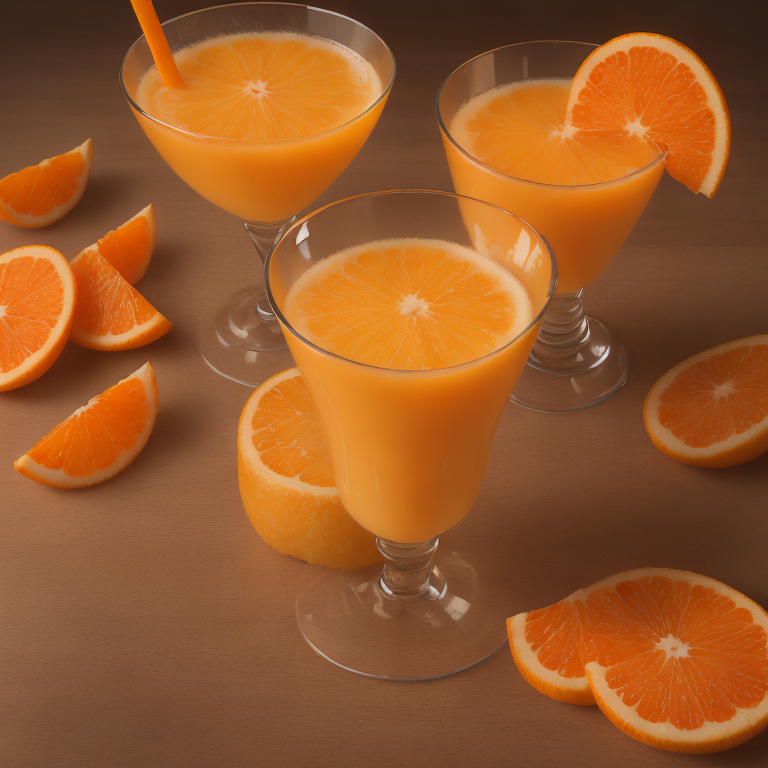

In [8]:
RUN_MINIMAL_EXAMPLE = True  # Set to True to execute a minimal render test with one target image. Requires GPU runtime for reasonable speed.

if RUN_MINIMAL_EXAMPLE:
    run_dir = create_run_dir(identity="starter_example")

    target_path = next(path for path in target_images if Path(path).name == "1159_25.png")
    example_prompt = "orange juice"

    generated = render_prompt_for_target(example_prompt, target_path)
    saved_path = save_generated_image(generated, run_dir, target_path, prompt_index=1)

    print("Target:", target_path)
    print("Seed:", seed_from_filename(target_path))
    print("Prompt:", example_prompt)
    print("Saved generated image:", saved_path)

    display(generated)
else:
    print("Optional render test skipped. Set RUN_MINIMAL_EXAMPLE = True to execute it in a GPU runtime.")


## 8. LLM-Based Refinement: Official Test Rounds

This section defines the selectable prompt rounds for the 10 official tests in `testes.txt`. All rounds keep the fixed TP2 generation configuration, only the prompt strategy changes.

Use `SELECTED_TEST_ROUND` in the next section to choose which test to render and evaluate.


In [10]:
PROJECT_TARGET_NAMES = [
    "1159_25.png",
    "1159_29.png",
    "1159_3.png",
    "1159_7.png",
    "7836.png",
    "9338.png",
]

# These notes describe what we see in the target figure. They help the LLM propose focused prompt edits.
target_notes = {
    "1159_25.png": "a clear glass of orange juice with a slice stuck on the rim of the glass, on a wooden table, surrounded by orange slices and a small trail of orange segments beside it",
    "1159_29.png": "single palm tree spawned in the ocean with waves, sunset near horizon, painterly realistic style",
    "1159_3.png": "a blond warrior in armor, with wings that are half fire and half water, and a sort of fiery tail protruding from the armor at the base of his neck, holding two swords of smoke dark concept art",
    "1159_7.png": "small fluffy capybara-like animal emerging from or sitting inside a beige cube, warm studio lighting",
    "7836.png": "an astronaut standing on a planet or moon surface, huge galaxy and planet horizon, cinematic sci-fi scene",
    "9338.png": "colorful cute fantasy rodent creature, rainbow fur, decorative beads, vibrant magical background",
}

baseline_candidate_prompts = {
    "1159_25.png": [
        "a glass of fresh orange juice with orange slices, studio still life, warm brown background, soft realistic lighting, high detail",
        "fresh orange juice in a clear glass, sliced oranges around it, warm tabletop still life, shallow depth of field, photorealistic",
        "orange juice glass with citrus slices and peel pieces, cozy studio product photography, amber background, realistic food photo",
        "a full glass of orange juice garnished with orange slices, warm soft light, brown surface, commercial beverage photography",
    ],
    "1159_29.png": [
        "a lone palm tree on a tropical beach at sunset, ocean waves, cloudy sky, painterly realistic seascape, high detail",
        "tropical island beach with one palm tree, sun setting over the ocean, turquoise waves, cinematic digital painting",
        "single palm tree beside the sea, golden sunset on the horizon, dramatic clouds, realistic fantasy landscape art",
        "palm tree standing in shallow ocean water at sunset, waves and distant island, soft atmospheric painting",
    ],
    "1159_3.png": [
        "blonde fantasy warrior man in silver armor, orange fire magic and teal smoke, dark background, concept art, high detail",
        "anime style armored male knight with blonde hair, glowing fire sword, teal magical smoke, dramatic fantasy illustration",
        "male paladin warrior in metallic armor surrounded by orange flames and turquoise mist, dark fantasy character art",
        "blonde armored hero holding fiery magic, teal and orange elemental energy, moody digital painting",
    ],
    "1159_7.png": [
        "a tiny fluffy capybara curled inside a beige cube made of soft blocks, warm studio lighting, surreal cute animal art",
        "small furry capybara-like animal with orange fur emerging from a cube of beige cushions, soft shadows, whimsical realistic render",
        "cute sleeping capybara cub nestled in a square beige block structure, warm brown background, soft detailed fur",
        "fluffy capybara-like creature sitting in a padded cube, cozy warm light, surreal photorealistic animal portrait",
    ],
    "7836.png": [
        "astronaut standing on a barren planet looking at a huge galaxy and planetary horizon, cinematic sci-fi, dark blue space",
        "lone astronaut on an alien moon, enormous planet rising, bright galaxy across the sky, epic science fiction concept art",
        "space explorer on a rocky planet surface under a vast nebula, distant glowing horizon, cinematic digital painting",
        "small astronaut silhouette facing a giant planet and starry galaxy, dramatic cosmic landscape, high detail",
    ],
    "9338.png": [
        "cute colorful fantasy hamster creature with rainbow fur and beads, magical glowing background, whimsical digital art",
        "small adorable rainbow squirrel with decorative jewelry, vibrant fantasy creature portrait, colorful painterly style",
        "fluffy multicolored rodent creature holding a glowing orb, rainbow wings of light, magical fantasy illustration",
        "cute fantasy animal with orange face, rainbow fur, blue gemstone chest, vivid magical background, high detail",
    ],
}

TARGET_BLUEPRINTS = {
    "1159_25.png": {
        "subject": "clear glass of orange juice with an orange slice on the rim",
        "short_subject": "orange juice glass with rim slice",
        "setting": "wooden tabletop still life with scattered orange slices, halved oranges, and small orange segments",
        "style": "realistic food and beverage photography",
        "clean_style": "clean commercial food photography",
        "light": "soft warm studio light",
        "color": "orange juice, amber highlights, and warm brown wood tones",
        "composition": "centered close-up with fruit arranged around the glass",
        "camera": "shallow depth of field product shot",
        "mood": "cozy appetizing beverage still life",
    },
    "1159_29.png": {
        "subject": "single palm tree growing from the ocean",
        "short_subject": "lone palm tree in ocean waves",
        "setting": "open sea with waves around the trunk and sunset near the horizon",
        "style": "painterly realistic seascape",
        "clean_style": "realistic tropical ocean landscape painting",
        "light": "golden sunset glow near the horizon",
        "color": "turquoise ocean water, golden orange sky, and dark palm silhouette",
        "composition": "wide horizon view centered on the solitary palm tree",
        "camera": "low ocean-level perspective",
        "mood": "calm cinematic ocean sunset scene",
    },
    "1159_3.png": {
        "subject": "blond male warrior in silver armor with wings split between fire and water",
        "short_subject": "armored blond elemental warrior",
        "setting": "dark fantasy background with smoke-dark dual swords and elemental energy",
        "style": "detailed dark fantasy concept art",
        "clean_style": "clean fantasy character concept illustration",
        "light": "dramatic orange fire glow and teal water-mist glow",
        "color": "orange flames, turquoise mist, silver armor, and black smoke",
        "composition": "centered heroic character portrait with visible elemental wings and weapons",
        "camera": "heroic half-body close-up framing",
        "mood": "moody high-contrast dark fantasy character art",
    },
    "1159_7.png": {
        "subject": "small fluffy spiky capybara-like creature emerging from a beige cube",
        "short_subject": "spiky fluffy capybara in beige cube",
        "setting": "warm studio scene with a geometric cube made of stacked soft beige blocks",
        "style": "surreal cute realistic 3D animal render",
        "clean_style": "clean whimsical 3D creature portrait",
        "light": "soft warm studio lighting with gentle shadows",
        "color": "golden orange fur, beige block tones, and warm brown background",
        "composition": "centered cube with the creature emerging from inside",
        "camera": "close-up square portrait composition",
        "mood": "cozy surreal cute creature scene",
    },
    "7836.png": {
        "subject": "astronaut standing on a barren moon or planet surface facing a huge planet horizon",
        "short_subject": "astronaut facing giant planet horizon",
        "setting": "rocky alien surface beneath a vast galaxy, nebula, and enormous reddish planet",
        "style": "cinematic science fiction concept art",
        "clean_style": "epic cinematic sci-fi landscape",
        "light": "dramatic cosmic horizon light with blue and orange contrast",
        "color": "deep blue space, bright nebula colors, and reddish planetary glow",
        "composition": "small astronaut foreground facing a vast cosmic sky and planet horizon",
        "camera": "wide cinematic landscape view",
        "mood": "lonely epic cosmic exploration scene",
    },
    "9338.png": {
        "subject": "cute fantasy rodent creature with rainbow fur, small horns, and decorative beads",
        "short_subject": "rainbow fantasy rodent with beads",
        "setting": "vibrant fiery magical background with warm orange, yellow, red, and green swirls",
        "style": "whimsical fantasy creature portrait illustration",
        "clean_style": "clean colorful magical creature portrait",
        "light": "glowing magical light around the creature",
        "color": "rainbow fur, pearl bead details, warm fiery background colors, and jewel-like accents",
        "composition": "centered cute creature portrait with decorative bead details visible",
        "camera": "close-up portrait framing",
        "mood": "playful adorable magical creature scene",
    },
}

def prompt_round_from_templates(templates):
    return {
        target_name: [template.format(**TARGET_BLUEPRINTS[target_name]) for template in templates]
        for target_name in PROJECT_TARGET_NAMES
    }

TEST_ROUNDS = {
    "baseline": {
        "round": 1,
        "folder_name": "baseline",
        "label": "Teste 01 - Baseline inicial",
        "description": "Prompts iniciais do notebook, sem alteracoes.",
        "prompts": baseline_candidate_prompts,
    },
    "teste_02": {
        "round": 2,
        "folder_name": "teste_02",
        "label": "Teste 02 - Prompts curtos e diretos",
        "description": "Prompts curtos com objeto principal primeiro, ambiente depois e estilo no fim.",
        "prompts": prompt_round_from_templates([
            "{short_subject}, {setting}, {style}",
            "{short_subject}, {light}, {clean_style}",
            "{subject}, {color}, {style}",
            "{short_subject}, {mood}",
        ]),
    },
    "teste_03": {
        "round": 3,
        "folder_name": "teste_03",
        "label": "Teste 03 - Prompts com composicao espacial",
        "description": "Prompts focados no enquadramento, escala e posicao dos elementos.",
        "prompts": prompt_round_from_templates([
            "{subject}, {composition}, {setting}, {style}",
            "{subject}, {camera}, {composition}, {light}",
            "{composition}, {subject}, clear foreground and background, {style}",
            "{subject}, balanced symmetrical composition, {setting}, {mood}",
        ]),
    },
    "teste_04": {
        "round": 4,
        "folder_name": "teste_04",
        "label": "Teste 04 - Prompts com luz e cor",
        "description": "Prompts focados em paleta, iluminacao, contraste e atmosfera.",
        "prompts": prompt_round_from_templates([
            "{subject}, {light}, {color}, {style}",
            "{subject}, rich {color}, controlled shadows, {setting}",
            "{subject}, {light}, high contrast but natural colors, {mood}",
            "{color}, {subject}, {setting}, soft atmospheric lighting",
        ]),
    },
    "teste_05": {
        "round": 5,
        "folder_name": "teste_05",
        "label": "Teste 05 - Prompts com estilo artistico especifico",
        "description": "Prompts que testam estilos visuais diferentes mantendo o mesmo conteudo.",
        "prompts": prompt_round_from_templates([
            "{subject}, photorealistic, {setting}, {light}",
            "{subject}, cinematic digital painting, {setting}, {color}",
            "{subject}, detailed concept art, {composition}, {mood}",
            "{subject}, realistic 3d render, {light}, {camera}",
        ]),
    },
    "teste_06": {
        "round": 6,
        "folder_name": "teste_06",
        "label": "Teste 06 - Prompts mais limpos e controlados",
        "description": "Prompts contidos para reduzir ruido e elementos extra.",
        "prompts": prompt_round_from_templates([
            "{subject}, simple {setting}, {clean_style}",
            "{subject}, uncluttered scene, {composition}, {light}",
            "{subject}, clean background, natural proportions, {style}",
            "{short_subject}, minimal extra objects, {color}, {clean_style}",
        ]),
    },
    "teste_07": {
        "round": 7,
        "folder_name": "teste_07",
        "label": "Teste 07 - Prompts orientados por target individual",
        "description": "Prompts mais especificos por target, baseados na observacao visual.",
        "prompts": {
            "1159_25.png": [
                "clear glass of orange juice with orange slice on rim, wooden table surface, scattered orange slices and segments around, warm lighting, food photography style, realistic details",
                "fresh orange juice in transparent glass garnished with citrus slice, brown tabletop still life, surrounded by halved oranges and small orange pieces, soft natural light, photorealistic beverage shot",
                "orange juice glass with slice stuck on edge, rustic wooden background, orange halves and fruit segments scattered nearby, cozy warm tones, commercial product photography, high detail",
                "a tumbler filled with fresh orange juice, decorated with orange wheel on rim, placed on wood table with sliced oranges and pulp pieces around, studio lighting, appetizing food photo",
            ],
            "1159_29.png": [
                "solitary palm tree in the middle of the sea, sunset glow near horizon, gentle waves around trunk, soft painterly lighting, realistic landscape illustration",
                "palm tree growing from the ocean with waves lapping at base, golden hour sunset, distant horizon glow, painterly digital art, detailed foliage and water",
                "lonely palm tree in open sea waters, dramatic sunset near horizon line, moving waves and clouds, semi-realistic painting technique, cinematic composition",
                "lone palm tree standing in the ocean waves at sunset, golden horizon light, dramatic cloudy sky, painterly realistic seascape art, detailed water reflections",
            ],
            "1159_3.png": [
                "blonde warrior in silver armor with dual elemental wings half fire half water, fiery tendril emerging from neck base, wielding two smoke-dark swords, dark fantasy concept art, moody atmosphere",
                "armored blonde fighter with split wings of orange flame and teal mist, glowing fire tail at nape of neck, holding dual shadow swords, dark background, detailed character design, dramatic lighting",
                "blonde-haired warrior in metallic armor featuring hybrid fire-water wings, fiery appendage protruding from collar area, dual wielder of dark smoky blades, dark concept art style, high contrast",
                "fantasy armored character with blonde hair, wings split between fire and water elements, flame-like tail from neck base, two swords made of black smoke, dark atmospheric digital painting, concept art quality",
            ],
            "1159_7.png": [
                "fluffy spiky capybara-like creature with golden fur emerging from a beige cube made of stacked soft blocks, warm studio lighting, cute surreal 3D render, detailed texture",
                "small furry animal with orange spiky hair sitting inside a cube of pale beige blocks, warm brown background, soft shadows, photorealistic whimsical creature design",
                "adorable fluffy capybara hybrid with wild golden fur poking out of a geometric beige cube structure, cozy studio lighting, hyper-detailed fur texture, surreal animal portrait",
                "cute spiky-haired creature resembling capybara nestled in a cube composed of small beige blocks, warm ambient lighting, realistic 3D art style, soft atmospheric shadows",
            ],
            "7836.png": [
                "astronaut standing on barren moon surface facing enormous reddish planet on horizon, vibrant galaxy and nebula in dark space sky, epic cinematic sci-fi scene, dramatic lighting, highly detailed",
                "lone space explorer on alien planet ground, massive planet rising over horizon with glowing atmosphere, star-filled galaxy backdrop, cinematic composition, photorealistic digital art, moody blue and orange tones",
                "astronaut silhouette on rocky lunar surface looking at giant planet horizon, deep space with colorful nebula and stars, dramatic sci-fi concept art, atmospheric perspective, movie-quality rendering",
                "small astronaut figure standing on desolate planet terrain beneath vast cosmic sky, huge planetary body at horizon line, galaxy and cosmic dust visible, cinematic lighting, epic scale science fiction illustration",
            ],
            "9338.png": [
                "cute fantasy rodent creature with rainbow multicolored fur, small horns, decorative pearl beads on body, vibrant fiery magical background with orange yellow and green swirls, whimsical digital painting style, adorable expression",
                "adorable colorful hamster-like creature with rainbow gradient fur from orange to blue to pink, adorned with shiny beads and jewelry, glowing magical background with warm vibrant colors, fantasy creature portrait art, soft painterly details",
                "fluffy fantasy rodent with multicolor rainbow coat featuring tiny decorative beads embedded in fur, cute face with large eyes, small horn protrusions, vivid magical aura background with fire-like colors, enchanting digital illustration",
                "small cute fantasy animal resembling mouse or hamster with iridescent rainbow fur texture, ornamental bead decorations on chest and body, mystical vibrant background with swirling orange red yellow green colors, magical creature concept art, high detail whimsical style",
            ],
        },
    },
    "teste_08": {
        "round": 8,
        "folder_name": "teste_08",
        "label": "Teste 08 - Refinamento dos melhores candidatos",
        "description": "Variantes pequenas dos candidatos mais promissores.",
        "prompts": prompt_round_from_templates([
            "{subject}, {composition}, {light}, {style}, accurate target-like colors",
            "{subject}, {setting}, refined details, {color}, {clean_style}",
            "{subject}, closer to reference image, {camera}, {mood}",
            "{subject}, preserve main shapes, balanced lighting, {setting}, {style}",
        ]),
    },
    "teste_09": {
        "round": 9,
        "folder_name": "teste_09",
        "label": "Teste 09 - Ordem das palavras no prompt",
        "description": "Mesmos conceitos principais com ordem diferente no texto.",
        "prompts": prompt_round_from_templates([
            "{subject}, {setting}, {light}, {style}",
            "{setting}, {subject}, {style}, {light}",
            "{style}, {subject}, {composition}, {color}",
            "{light}, {color}, {subject}, {setting}",
        ]),
    },
    "teste_10": {
        "round": 10,
        "folder_name": "teste_10",
        "label": "Teste 10 - Ronda final candidata",
        "description": "Ronda final com os melhores prompts por target combinando os resultados dos testes 1 a 9.",
        "prompts": {
            "1159_25.png": [
                "clear glass of orange juice with orange slice on rim, centered close-up with fruit scattered around, soft warm studio light, clean commercial food photography, accurate target-like colors",
                "clear glass of orange juice with an orange slice on the rim, clean background, natural proportions, shallow depth of field, realistic food and beverage photography",
                "orange juice glass with slice stuck on rim, wooden tabletop, scattered orange slices around, soft warm light, commercial product photography, accurate colors",
                "clear glass of orange juice with an orange slice on the rim, shallow depth of field product shot, centered close-up with fruit arranged around the glass, soft warm studio light, accurate target-like colors",
            ],
            "1159_29.png": [
                "solitary palm tree in the middle of the sea, sunset glow near horizon, gentle waves around trunk, soft painterly lighting, realistic landscape illustration",
                "single palm tree growing from the ocean, closer to reference image, low ocean-level perspective, calm cinematic ocean sunset scene",
                "lone palm tree standing in the ocean waves, golden horizon light, gentle waves around base, painterly realistic seascape, ocean-level perspective",
                "lone palm tree standing in the ocean waves at sunset, golden horizon light, dramatic cloudy sky, painterly realistic seascape art, detailed water reflections",
            ],
            "1159_3.png": [
                "anime style armored male knight with blonde hair, glowing fire sword, teal magical smoke, dramatic fantasy illustration",
                "blonde male warrior in silver armor with wings split between fire and water, orange fire magic and teal smoke, dark background, anime concept art, accurate target-like colors",
                "blond male warrior in silver armor with wings split between fire and water, centered heroic character portrait with visible elemental wings and weapons, dramatic orange fire glow and teal water-mist glow, detailed dark fantasy concept art, accurate target-like colors",
                "armored blonde fighter with split wings of orange flame and teal mist, glowing fire tail at nape of neck, holding dual shadow swords, dark background, anime fantasy illustration style, dramatic lighting",
            ],
            "1159_7.png": [
                "adorable fluffy capybara hybrid with wild golden fur poking out of a geometric beige cube structure, cozy studio lighting, hyper-detailed fur texture, surreal animal portrait",
                "small fluffy spiky capybara-like creature emerging from a beige cube, golden orange spiky fur, beige block tones, warm studio lighting, surreal cute realistic 3D render",
                "fluffy capybara-like creature with wild golden fur emerging from inside a beige cube of stacked blocks, centered composition, cozy warm studio light, hyper-detailed fur texture, realistic 3D animal art",
                "small fluffy spiky capybara-like creature emerging from a beige cube, closer to reference image, close-up square portrait composition, cozy surreal cute creature scene",
            ],
            "7836.png": [
                "astronaut standing on a barren moon or planet surface facing a huge planet horizon, rich deep blue space, bright nebula colors, and reddish planetary glow, controlled shadows, rocky alien surface beneath a vast galaxy, nebula, and enormous reddish planet",
                "astronaut standing on a barren moon or planet surface facing a huge planet horizon, cinematic digital painting, rocky alien surface beneath a vast galaxy, nebula, and enormous reddish planet, deep blue space, bright nebula colors, and reddish planetary glow",
                "small astronaut foreground facing a vast cosmic sky and planet horizon, enormous reddish planet on horizon, deep blue space with nebula, cinematic science fiction concept art, dramatic lighting",
                "astronaut standing on barren moon surface, cinematic digital painting, rich deep blue space, bright nebula and reddish planet on horizon, dramatic cosmic lighting, epic sci-fi landscape",
            ],
            "9338.png": [
                "cute fantasy rodent creature with rainbow fur, small horns, and decorative beads, vibrant fiery magical background with warm orange, yellow, red, and green swirls, glowing magical light around the creature, whimsical fantasy creature portrait illustration",
                "fluffy fantasy rodent with multicolor rainbow coat featuring tiny decorative beads embedded in fur, cute face with large eyes, small horn protrusions, vivid magical aura background with fire-like colors, enchanting digital illustration",
                "cute fantasy rodent with rainbow multicolored fur, small horns, decorative pearl beads, glowing magical light, vibrant fiery background with orange yellow green swirls, whimsical fantasy creature portrait",
                "cute fantasy rodent creature with rainbow fur, small horns, and decorative beads, preserve main shapes, balanced lighting, vibrant fiery magical background, whimsical fantasy creature portrait illustration",
            ],
        },
    },
}

candidate_prompts = TEST_ROUNDS["baseline"]["prompts"]
AVAILABLE_TEST_ROUNDS = list(TEST_ROUNDS.keys())
print("Available test rounds:", ", ".join(AVAILABLE_TEST_ROUNDS))


Available test rounds: baseline, teste_02, teste_03, teste_04, teste_05, teste_06, teste_07, teste_08, teste_09, teste_10


## 9. Render, Evaluate, and Rank the Selected Test Round

Choose one official round with `SELECTED_TEST_ROUND`, then set `RUN_FULL_REFINEMENT_ROUND = True` to render only that test.

Each run creates a named folder inside `OUTPUT_DIR`, such as `baseline`, `teste_02`, or `teste_10`. If that folder already exists, the notebook creates a numbered variant instead of overwriting it.


In [11]:
METRIC_COLUMNS = ["clip_similarity", "lpips_alex", "pixel_rmse"]


def normalize_higher_is_better(values):
    values = pd.Series(values, dtype="float64")
    if values.max() == values.min():
        return pd.Series([1.0] * len(values), index=values.index)
    return (values - values.min()) / (values.max() - values.min())


def normalize_lower_is_better(values):
    values = pd.Series(values, dtype="float64")
    if values.max() == values.min():
        return pd.Series([1.0] * len(values), index=values.index)
    return 1.0 - (values - values.min()) / (values.max() - values.min())


def rank_candidates(rows):
    ranked_groups = []
    df = pd.DataFrame(rows)
    if df.empty:
        return df

    for target_name, group in df.groupby("target_name", sort=False):
        group = group.copy()
        group["clip_norm"] = normalize_higher_is_better(group["clip_similarity"])
        group["lpips_norm"] = normalize_lower_is_better(group["lpips_alex"])
        group["rmse_norm"] = normalize_lower_is_better(group["pixel_rmse"])
        group["selection_score"] = (
            0.50 * group["clip_norm"] +
            0.35 * group["lpips_norm"] +
            0.15 * group["rmse_norm"]
        )
        group = group.sort_values(
            ["selection_score", "clip_similarity", "lpips_alex", "pixel_rmse"],
            ascending=[False, False, True, True],
        ).reset_index(drop=True)
        group["rank"] = np.arange(1, len(group) + 1)
        ranked_groups.append(group)

    return pd.concat(ranked_groups, ignore_index=True)


def metric_summary(df, label):
    if df.empty:
        return pd.DataFrame(columns=["set", "target_name", "metric", "mean", "std"])
    rows = []
    for target_name, group in df.groupby("target_name", sort=False):
        agg = group[METRIC_COLUMNS].agg(["mean", "std"]).T.reset_index()
        agg.columns = ["metric", "mean", "std"]
        agg.insert(0, "target_name", target_name)
        agg.insert(0, "set", label)
        rows.append(agg)
    return pd.concat(rows, ignore_index=True)


def save_dataframe_outputs(df, path_without_suffix):
    path_without_suffix = Path(path_without_suffix)
    df.to_csv(path_without_suffix.with_suffix(".csv"), index=False)
    path_without_suffix.with_suffix(".json").write_text(
        df.to_json(orient="records", indent=2, force_ascii=False),
        encoding="utf-8",
    )


def create_unique_named_run_dir(base_dir, folder_name):
    base_dir = Path(base_dir)
    run_dir = base_dir / folder_name
    if not run_dir.exists():
        run_dir.mkdir(parents=True, exist_ok=False)
        return run_dir

    suffix = 2
    while True:
        candidate = base_dir / f"{folder_name}_{suffix:02d}"
        if not candidate.exists():
            candidate.mkdir(parents=True, exist_ok=False)
            return candidate
        suffix += 1


def get_test_round(round_key):
    if round_key not in TEST_ROUNDS:
        available = ", ".join(TEST_ROUNDS.keys())
        raise KeyError(f"Unknown test round '{round_key}'. Available rounds: {available}")
    return TEST_ROUNDS[round_key]


def render_evaluate_rank_round(round_key=None, top_k=3):
    round_key = round_key or SELECTED_TEST_ROUND
    round_config = get_test_round(round_key)
    prompts_by_target = round_config["prompts"]
    run_dir = create_unique_named_run_dir(OUTPUT_DIR, round_config["folder_name"])
    target_by_name = {Path(path).name: path for path in target_images}
    rows = []

    print("Selected round:", round_key)
    print("Round label:", round_config["label"])
    print("Round description:", round_config["description"])
    print("Output folder:", run_dir)

    for target_name in PROJECT_TARGET_NAMES:
        target_path = target_by_name.get(target_name)
        if target_path is None:
            print("Skipping missing target:", target_name)
            continue

        prompts = prompts_by_target.get(target_name, [])
        if not prompts:
            print("No prompts for target:", target_name)
            continue

        seed = seed_from_filename(target_path, config.seed)
        for candidate_index, prompt in enumerate(prompts, start=1):
            print(f"Rendering {target_name} candidate {candidate_index}/{len(prompts)}")
            generated = render_prompt(prompt, seed=seed)
            render_path = save_generated_image(generated, run_dir, target_path, prompt_index=candidate_index)
            metrics = evaluate_render(target_path, render_path)
            rows.append({
                "round": int(round_config["round"]),
                "test_key": round_key,
                "test_label": round_config["label"],
                "target": str(target_path),
                "target_name": target_name,
                "render_seed": seed,
                "candidate_index": candidate_index,
                "prompt": prompt,
                "render": str(render_path),
                **metrics,
            })

    ranked_df = rank_candidates(rows)
    top_df = ranked_df[ranked_df["rank"] <= top_k].copy() if not ranked_df.empty else ranked_df.copy()
    summary_df = pd.concat([
        metric_summary(ranked_df, "all_candidates"),
        metric_summary(top_df, f"top_{top_k}"),
    ], ignore_index=True)

    save_dataframe_outputs(ranked_df, run_dir / "ranked_candidates")
    save_dataframe_outputs(top_df, run_dir / f"top_{top_k}_candidates")
    save_dataframe_outputs(summary_df, run_dir / "metric_summary")
    write_csv(run_dir / "generated_prompts.csv", rows)

    print("Saved run to:", run_dir)
    print("Generated", len(rows), "candidate image(s)")
    return run_dir, ranked_df, top_df, summary_df


# Choose one official test round before running.
# Options: baseline, teste_02, teste_03, teste_04, teste_05, teste_06, teste_07, teste_08, teste_09, teste_10
SELECTED_TEST_ROUND = "teste_10"
RUN_FULL_REFINEMENT_ROUND = True  # Set to True to execute the selected test round. Make sure to choose the round above before enabling this.

selected_round_config = get_test_round(SELECTED_TEST_ROUND)
LLM_REFINEMENT_ROUND = int(selected_round_config["round"])
candidate_prompts = selected_round_config["prompts"]

print("Selected test round:", SELECTED_TEST_ROUND)
print("Round label:", selected_round_config["label"])
print("Output folder name:", selected_round_config["folder_name"])
print("Set RUN_FULL_REFINEMENT_ROUND = True to execute this selected round.")

if RUN_FULL_REFINEMENT_ROUND:
    run_dir, ranked_df, top3_df, summary_df = render_evaluate_rank_round(SELECTED_TEST_ROUND, top_k=3)
    display(top3_df[["test_key", "target_name", "rank", "prompt", "clip_similarity", "lpips_alex", "pixel_rmse", "selection_score"]])
    display(summary_df)
else:
    print("Full refinement round skipped.")


Selected test round: teste_10
Round label: Teste 10 - Ronda final candidata
Output folder name: teste_10
Set RUN_FULL_REFINEMENT_ROUND = True to execute this selected round.
Selected round: teste_10
Round label: Teste 10 - Ronda final candidata
Round description: Ronda final com os melhores prompts por target combinando os resultados dos testes 1 a 9.
Output folder: /content/drive/MyDrive/content/GENAI_TP2/outputs/teste_10
Rendering 1159_25.png candidate 1/4


  0%|          | 0/8 [00:00<?, ?it/s]

Rendering 1159_25.png candidate 2/4


  0%|          | 0/8 [00:00<?, ?it/s]

Rendering 1159_25.png candidate 3/4


...

Rendering 9338.png candidate 4/4


  0%|          | 0/8 [00:00<?, ?it/s]

Saved run to: /content/drive/MyDrive/content/GENAI_TP2/outputs/teste_10
Generated 24 candidate image(s)


,test_key,target_name,rank,prompt,clip_similarity,lpips_alex,pixel_rmse,selection_score
0,teste_10,1159_25.png,1,clear glass of orange juice with orange slice ...,0.945382,0.368692,0.149479,1.000000
1,teste_10,1159_25.png,2,clear glass of orange juice with an orange sli...,0.939713,0.455606,0.172497,0.682065
2,teste_10,1159_25.png,3,"orange juice glass with slice stuck on rim, wo...",0.928064,0.492141,0.158089,0.445987
4,teste_10,1159_29.png,1,"single palm tree growing from the ocean, close...",0.907993,0.693568,0.190473,0.949850
5,teste_10,1159_29.png,2,"solitary palm tree in the middle of the sea, s...",0.912605,0.759656,0.221863,0.824580
6,teste_10,1159_29.png,3,"lone palm tree standing in the ocean waves, go...",0.866626,0.836545,0.261412,0.115510
8,teste_10,1159_3.png,1,anime style armored male knight with blonde ha...,0.830074,0.575177,0.184379,0.891232
9,teste_10,1159_3.png,2,blond male warrior in silver armor with wings ...,0.801329,0.602897,0.155370,0.530553
10,teste_10,1159_3.png,3,blonde male warrior in silver armor with wings...,0.748221,0.577028,0.176816,0.399966
12,teste_10,1159_7.png,1,adorable fluffy capybara hybrid with wild gold...,0.740923,0.455158,0.121625,0.889642


,set,target_name,metric,mean,std
0,all_candidates,1159_25.png,clip_similarity,0.932075,0.013394
1,all_candidates,1159_25.png,lpips_alex,0.464574,0.073045
2,all_candidates,1159_25.png,pixel_rmse,0.175175,0.031759
3,all_candidates,1159_29.png,clip_similarity,0.890302,0.023361
4,all_candidates,1159_29.png,lpips_alex,0.792549,0.082739
5,all_candidates,1159_29.png,pixel_rmse,0.238854,0.040707
6,all_candidates,1159_3.png,clip_similarity,0.793043,0.033908
7,all_candidates,1159_3.png,lpips_alex,0.590824,0.017152
8,all_candidates,1159_3.png,pixel_rmse,0.177985,0.016893
9,all_candidates,1159_7.png,clip_similarity,0.732876,0.032948


## 10. LLM Feedback Files and Contact Sheets

After a scored round, this section creates contact sheets and a Markdown request that can be given to an LLM for the next refinement round.

In [12]:
import textwrap
from PIL import ImageDraw, ImageOps


def wrap_label(text, width=34, max_lines=3):
    lines = textwrap.wrap(str(text), width=width)
    return "\n".join(lines[:max_lines])


def make_labeled_tile(image, label, tile_size=256, label_height=78):
    image = ImageOps.fit(image.convert("RGB"), (tile_size, tile_size), method=Image.Resampling.LANCZOS)
    tile = Image.new("RGB", (tile_size, tile_size + label_height), "white")
    tile.paste(image, (0, 0))
    draw = ImageDraw.Draw(tile)
    draw.text((8, tile_size + 8), wrap_label(label), fill=(20, 20, 20))
    return tile


def build_contact_sheets(ranked_df, run_dir, max_candidates=6):
    contact_dir = Path(run_dir) / "contact_sheets"
    contact_dir.mkdir(parents=True, exist_ok=True)
    contact_paths = {}

    for target_name, group in ranked_df.groupby("target_name", sort=False):
        group = group.sort_values("rank")
        tiles = []
        target_path = group.iloc[0]["target"]
        tiles.append(make_labeled_tile(load_image(target_path), f"TARGET: {target_name}"))

        for _, row in group.head(max_candidates).iterrows():
            label = (
                f"rank {int(row['rank'])} | cand {int(row['candidate_index'])} | "
                f"score {row['selection_score']:.3f}\n"
                f"CLIP {row['clip_similarity']:.3f} | LPIPS {row['lpips_alex']:.3f} | RMSE {row['pixel_rmse']:.3f}"
            )
            tiles.append(make_labeled_tile(load_image(row["render"]), label))

        cols = min(4, len(tiles))
        rows = math.ceil(len(tiles) / cols)
        tile_width, tile_height = tiles[0].size
        sheet = Image.new("RGB", (cols * tile_width, rows * tile_height), "white")
        for index, tile in enumerate(tiles):
            x = (index % cols) * tile_width
            y = (index // cols) * tile_height
            sheet.paste(tile, (x, y))

        path = contact_dir / f"{safe_stem(target_name)}_round_{LLM_REFINEMENT_ROUND:02d}.jpg"
        sheet.save(path, quality=95)
        contact_paths[target_name] = path

    return contact_paths


def write_llm_refinement_requests(ranked_df, run_dir, contact_paths, max_candidates=6, prompts_to_request=8):
    round_key = ranked_df["test_key"].iloc[0] if "test_key" in ranked_df.columns and not ranked_df.empty else SELECTED_TEST_ROUND
    round_config = get_test_round(round_key)

    lines = [
        "# LLM Refinement Requests",
        "",
        f"Selected test round: {round_key}",
        f"Round label: {round_config['label']}",
        f"Round description: {round_config['description']}",
        f"Output folder: {run_dir}",
        "",
        "Use these requests after inspecting the target and the rendered candidates.",
        "The LLM should propose discrete English prompts only; the LCM model, seed, resolution, guidance, origin steps, and inference steps stay fixed.",
        "",
        f"Fixed model: {config.model_id}",
        f"Resolution: {config.width}x{config.height}",
        f"Guidance scale: {config.guidance_scale}",
        f"LCM origin steps: {config.lcm_origin_steps}",
        f"Inference steps: {config.num_inference_steps}",
        "",
    ]

    for target_name in PROJECT_TARGET_NAMES:
        group = ranked_df[ranked_df["target_name"] == target_name].sort_values("rank")
        if group.empty:
            continue

        seed = int(group.iloc[0]["render_seed"])
        lines.extend([
            f"## {target_name}",
            "",
            f"Target visual note: {target_notes.get(target_name, '')}",
            f"Render seed: {seed}",
            f"Contact sheet: {contact_paths.get(target_name, '')}",
            "",
            "Current scored candidates:",
        ])

        for _, row in group.head(max_candidates).iterrows():
            lines.append(
                f"- Rank {int(row['rank'])}, candidate {int(row['candidate_index'])}: "
                f"CLIP={row['clip_similarity']:.4f}, LPIPS={row['lpips_alex']:.4f}, RMSE={row['pixel_rmse']:.4f}, "
                f"prompt=\"{row['prompt']}\""
            )

        lines.extend([
            "",
            f"Task for the LLM: propose {prompts_to_request} improved prompts for this target.",
            "Keep the strongest visual elements from the best candidates, change only the prompt text, and return a Python list of strings.",
            "",
        ])

    request_path = Path(run_dir) / "llm_refinement_requests.md"
    request_path.write_text("\n".join(lines), encoding="utf-8")
    return request_path


if "ranked_df" in globals() and not ranked_df.empty:
    contact_paths = build_contact_sheets(ranked_df, run_dir)
    llm_request_path = write_llm_refinement_requests(ranked_df, run_dir, contact_paths)
    print("Saved contact sheets:")
    for path in contact_paths.values():
        print("-", path)
    print("Saved LLM refinement request:", llm_request_path)
else:
    print("No ranked results yet. Run a full refinement round before creating LLM feedback files.")


Saved contact sheets:
- /content/drive/MyDrive/content/GENAI_TP2/outputs/teste_10/contact_sheets/1159_25_round_10.jpg
- /content/drive/MyDrive/content/GENAI_TP2/outputs/teste_10/contact_sheets/1159_29_round_10.jpg
- /content/drive/MyDrive/content/GENAI_TP2/outputs/teste_10/contact_sheets/1159_3_round_10.jpg
- /content/drive/MyDrive/content/GENAI_TP2/outputs/teste_10/contact_sheets/1159_7_round_10.jpg
- /content/drive/MyDrive/content/GENAI_TP2/outputs/teste_10/contact_sheets/7836_round_10.jpg
- /content/drive/MyDrive/content/GENAI_TP2/outputs/teste_10/contact_sheets/9338_round_10.jpg
Saved LLM refinement request: /content/drive/MyDrive/content/GENAI_TP2/outputs/teste_10/llm_refinement_requests.md


## 11. Iteration and Report Checklist

Use one final methodology in the report: LLM-based refinement. A simple iteration is:

1. Run a refinement round on GPU/CUDA.
2. Inspect the target, generated candidates, contact sheets, and metric tables.
3. Give the generated `llm_refinement_requests.md` plus the contact sheet to an LLM.
4. Paste the improved prompts back into `candidate_prompts`.
5. Increment `LLM_REFINEMENT_ROUND` and repeat.
6. Keep the best top-3 prompts per target for the final report.

For the report, include the target image, top-3 prompts, top-3 rendered images, CLIP image-image similarity, LPIPS AlexNet distance, Pixel RMSE, and the mean/std summary across the selected candidates.